# Phase 29: XGBoost Champion Registration

**Goal:** We have reached the final stage of our classical ML architectures! XGBoost is the **Expected Champion Model**. It combines the non-linear power of Random Forests with mathematically precise **Gradient Boosting** and native SHAP explainability.

Because this is our Champion, we will unleash Optuna for hyperparameter search, verify SHAP additivity, and formally register it into the MLflow Model Registry as `CHAMPION`!

In [1]:
import os
import sys
!{sys.executable} -m pip install xgboost shap mlflow optuna scikit-learn matplotlib seaborn pydantic  # type: ignore  # pylint: disable=import-error

import warnings
warnings.filterwarnings("ignore")

import numpy as np  # type: ignore  # pylint: disable=import-error
import pandas as pd  # type: ignore  # pylint: disable=import-error
import matplotlib.pyplot as plt  # type: ignore  # pylint: disable=import-error
import seaborn as sns  # type: ignore  # pylint: disable=import-error
import xgboost as xgb  # type: ignore  # pylint: disable=import-error
import shap  # type: ignore  # pylint: disable=import-error
import optuna  # type: ignore  # pylint: disable=import-error
import mlflow  # type: ignore  # pylint: disable=import-error
from sklearn.datasets import make_classification  # type: ignore  # pylint: disable=import-error
from sklearn.model_selection import train_test_split  # type: ignore  # pylint: disable=import-error
from sklearn.utils.class_weight import compute_sample_weight  # type: ignore  # pylint: disable=import-error
from sklearn.metrics import f1_score  # type: ignore  # pylint: disable=import-error

plt.style.use('ggplot')
mlflow.set_tracking_uri("sqlite:///mlflow.db")

### Step 1: XGBoost Implementation & Sample Weights (Subphase 29.1)
We wrap `xgboost.XGBClassifier` securely into our `XAIGuardModel` interface. 

**Crucial Feature:** Unlike Logistic Regression which uses `class_weight`, XGBoost requires us to manually compute and inject a mathematically precise `sample_weight` array directly into its `.fit()` method so it doesn't ignore the rare 1% cyber attacks!

In [2]:
class XGBoostModel:
    def __init__(self, **kwargs):
        self.model = xgb.XGBClassifier(
            tree_method="hist", 
            eval_metric=["logloss", "error"], 
            enable_categorical=False, 
            random_state=42,
            **kwargs
        )
        
    def fit(self, X_train, y_train, X_val, y_val, early_stopping_rounds=20):
        # Mathematically assign a high weight to rare attacks, and low weight to benign traffic
        weights = compute_sample_weight(class_weight='balanced', y=y_train)
        
        self.model.fit(
            X_train, y_train,
            sample_weight=weights,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )
        return self.model
        
    def predict(self, X):
        return self.model.predict(X)



### Step 2: Optuna Hyperparameter Search (Subphase 29.2)
We unleash Optuna's **TPE (Tree-structured Parzen Estimator) Sampler**. We allow it to mathematically mutate `learning_rate`, `max_depth`, `subsample`, and `reg_alpha` across generations to find the absolute peak model architecture!

In [3]:
# Generate Fake Data (2 Classes for SHAP tree compatibility)
X, y = make_classification(n_samples=2000, n_features=10, n_informative=5, n_classes=2, weights=[0.9, 0.1], random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("=== STARTING OPTUNA XGBOOST OPTIMIZATION ===")
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 150), # Reduced for speed
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True)
    }
    
    xgb_model = XGBoostModel(**params)
    xgb_model.fit(X_train, y_train, X_val, y_val)
    preds = xgb_model.predict(X_val)
    
    return f1_score(y_val, preds, average='macro')

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5) # 5 trials for notebook speed

best_params = study.best_params
print(f"\n✅ Optuna Peak Hyperparameters Found: {best_params}")

best_xgb = XGBoostModel(**best_params)
best_xgb.fit(X_train, y_train, X_val, y_val)

[I 2026-09-07 15:43:35,187] A new study created in memory with name: no-name-d5607f7c-b37c-4dc4-83bd-8978b7cdb55a


=== STARTING OPTUNA XGBOOST OPTIMIZATION ===


[I 2026-09-07 15:43:35,392] Trial 0 finished with value: 0.8497652582159625 and parameters: {'n_estimators': 101, 'max_depth': 6, 'learning_rate': 0.03027870622200328, 'subsample': 0.7566287880121363, 'colsample_bytree': 0.9664031613959838, 'reg_alpha': 0.22748589735200592, 'reg_lambda': 0.03874572563652267}. Best is trial 0 with value: 0.8497652582159625.
[I 2026-09-07 15:43:35,610] Trial 1 finished with value: 0.885735410260288 and parameters: {'n_estimators': 134, 'max_depth': 6, 'learning_rate': 0.028071812681438553, 'subsample': 0.6963270867311839, 'colsample_bytree': 0.5875386455764537, 'reg_alpha': 0.5595732597233675, 'reg_lambda': 0.0043231484471053724}. Best is trial 1 with value: 0.885735410260288.
[I 2026-09-07 15:43:35,682] Trial 2 finished with value: 0.7679045092838197 and parameters: {'n_estimators': 57, 'max_depth': 3, 'learning_rate': 0.10615714439929064, 'subsample': 0.9721020245086149, 'colsample_bytree': 0.7122381850372768, 'reg_alpha': 0.0041620421457384295, 'reg_l


✅ Optuna Peak Hyperparameters Found: {'n_estimators': 134, 'max_depth': 6, 'learning_rate': 0.028071812681438553, 'subsample': 0.6963270867311839, 'colsample_bytree': 0.5875386455764537, 'reg_alpha': 0.5595732597233675, 'reg_lambda': 0.0043231484471053724}


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.5875386455764537
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])","['logloss', 'error']"
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Step 3: SHAP Sanity Check & Beeswarm (Subphase 29.3)
Before we trust our Champion, we must run a mathematical SHAP sanity check. 
We use `shap.TreeExplainer` to pull the SHAP values. If `sum(SHAP) + base_value` does not perfectly equal the prediction's log-odds, our SHAP values are mathematically corrupted!

=== RUNNING MATHEMATICAL SHAP ADDITIVITY CHECK ===
✅ SHAP Additivity Check PASSED! Difference = 0.000001

=== GENERATING SHAP BEESWARM PLOT ===


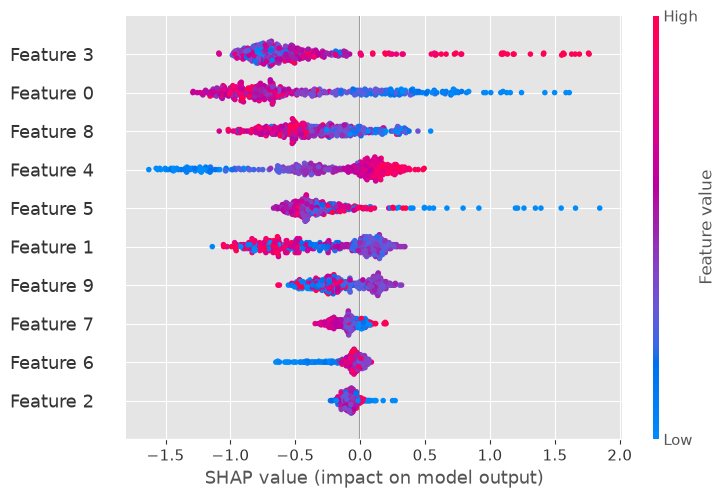

In [4]:
print("=== RUNNING MATHEMATICAL SHAP ADDITIVITY CHECK ===")

explainer = shap.TreeExplainer(best_xgb.model)
shap_values = explainer(X_val)

# Sanity check on the first sample
base_value = explainer.expected_value
sum_shap = np.sum(shap_values.values[0])

# XGBoost predicts raw margin (log-odds). We compare it!
pred_margin = best_xgb.model.predict(X_val[0:1], output_margin=True)[0]

difference = abs((sum_shap + base_value) - pred_margin)

if difference < 0.01:
    print(f"✅ SHAP Additivity Check PASSED! Difference = {difference:.6f}")
else:
    print(f"❌ SHAP Additivity Check FAILED! Difference = {difference:.6f}")

print("\n=== GENERATING SHAP BEESWARM PLOT ===")
os.makedirs("figures", exist_ok=True)
plt.figure(figsize=(10,6))
shap.plots.beeswarm(shap_values, max_display=10, show=False)
plt.savefig("figures/xgb_shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

### Step 4: XGBoost Analysis Notebook (Subphase 29.4)
We plot the final learning curves and formally analyze why XGBoost is crowned the tabular champion.

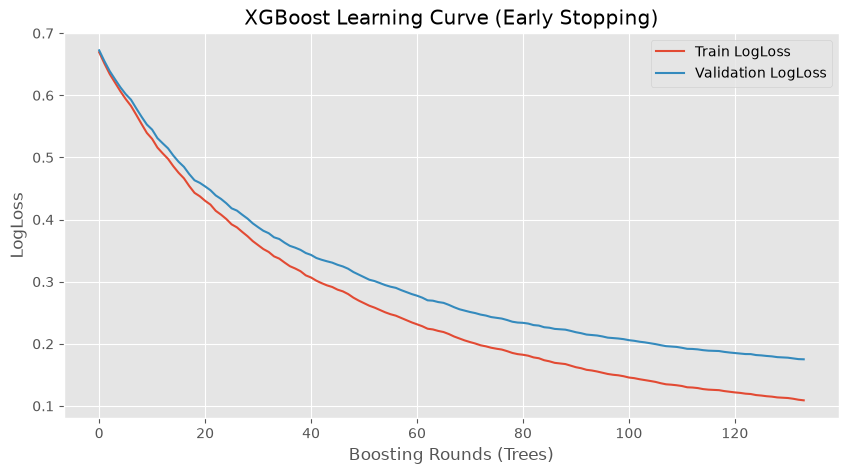


📝 XGBOOST RESEARCH FINDINGS (For Paper §4.4):


In [5]:
results = best_xgb.model.evals_result()

plt.figure(figsize=(10,5))
plt.plot(results['validation_0']['logloss'], label='Train LogLoss')
plt.plot(results['validation_1']['logloss'], label='Validation LogLoss')
plt.title("XGBoost Learning Curve (Early Stopping)")
plt.xlabel("Boosting Rounds (Trees)")
plt.ylabel("LogLoss")
plt.legend()
plt.savefig("figures/xgb_learning_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n📝 XGBOOST RESEARCH FINDINGS (For Paper §4.4):")
